# Demo of Convolutional Neural Network from Scratch

In [2]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_openml

from src.layers import Conv2D, MaxPool, Flatten, FullyConnected, BatchNorm2D, ReLU
from src.activations import relu, softmax
from src.losses import cross_entropy_loss
from src.optimizers import Adam   
from src.model import Model 
from src.train import train, one_hot

## Data Loading

First step before splitting the data into trainable data is to fetch version one of MNIST from scikit learn as the data we're going to train our Convolutional Neural Network on. This will provide the images and labels, allowing us to see how efficient our model operates.

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

## Data Preprocessing

### Splitting the Data into Appropriate Sections

The next step is for us to drop off pieces of data into a training and test labels and images, to first train our model up, then to see it's accuracy after.

In [4]:
# training images and labels
x_train = mnist.data[:60000].reshape(60000, 1, 28, 28) 
y_train = mnist.target[:60000].astype(int)

# test images and labels
x_test = mnist.data[60000:].reshape(-1, 1, 28, 28)
y_test = mnist.target[60000:].astype(int)

### Normalizing Data
The next step is to normalize the data to ensure that is able to train properly and eliminate any possible outliers which might impact the data by making all the `x_train` and `x_test` (images) a value from range of **0.0** to **1.0** by dividing it by **255** as colors range on that scale.

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### One-hot Encoding

For the labels (`y_train` and `y_test`) it is necessary to use one-hot encoding in order for the data outputted to match that of the data outputted by the fully connected layer and softmax in the convolutional neural network.

In [6]:
y_train = one_hot(y_train, num_classes=10)
y_test = one_hot(y_test, num_classes=10)

### Verifiying Data

The first step we take into verifying the data is seeing if it is appropriately displaying the images in a correct black and white format and, is able to display the appropriate and related labels to it in the right format.

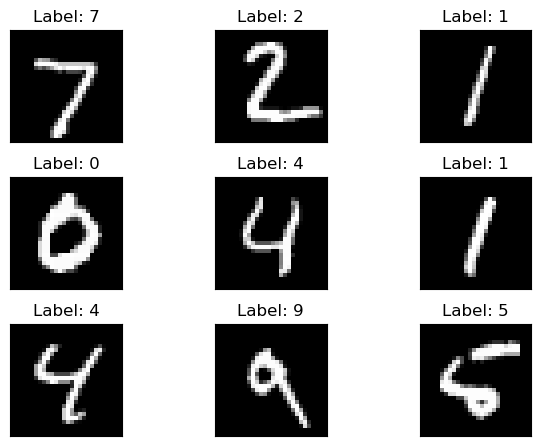

In [7]:
fig = plt.figure()
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.tight_layout()
    plt.imshow(x_test[i][0], cmap='gray', interpolation='none')
    plt.title("Label: {}".format(np.argmax(y_test[i])))    
    plt.xticks([])
    plt.yticks([])
plt.show()


The next initiative to take is ensuring that the data is split across the different labels in an appropriate manner, and to display that we will be using a bar chart as a measure of ensuring the data is loaded correctly.

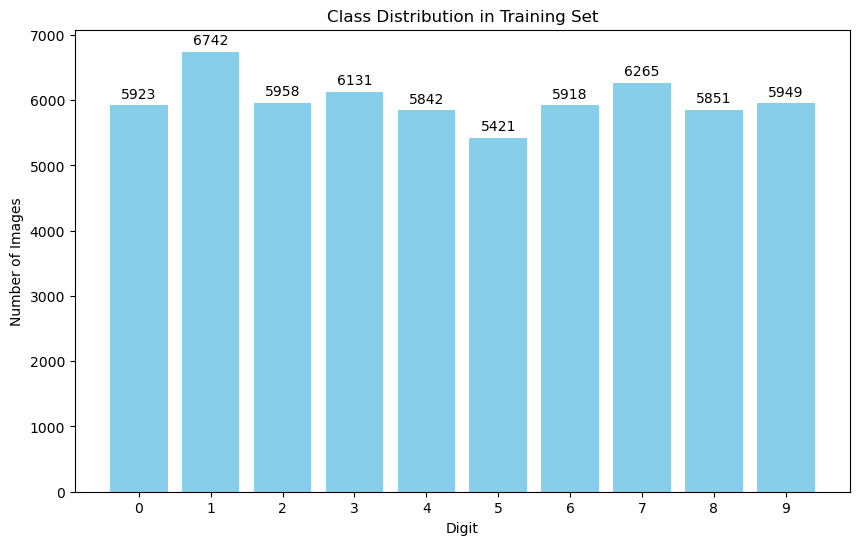

In [8]:
y_train_labels = np.argmax(y_train, axis=1)   # (60000, 10) → (60000,)

counts = pd.Series(y_train_labels).value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(counts.index, counts.values, color='skyblue')
plt.bar_label(bars, padding=3)
plt.title('Class Distribution in Training Set')
plt.xlabel('Digit')
plt.ylabel('Number of Images')
plt.xticks(range(10))  
plt.show()

We then have to ensure ourselves that the training images are appropriately normalized, and we can see this through a histogram, this histogram would display the amount of frequency for each pixel intensity and with it being black and white images now we can massively expect spikes at the 0.0 and 1.0 pixel intensity.

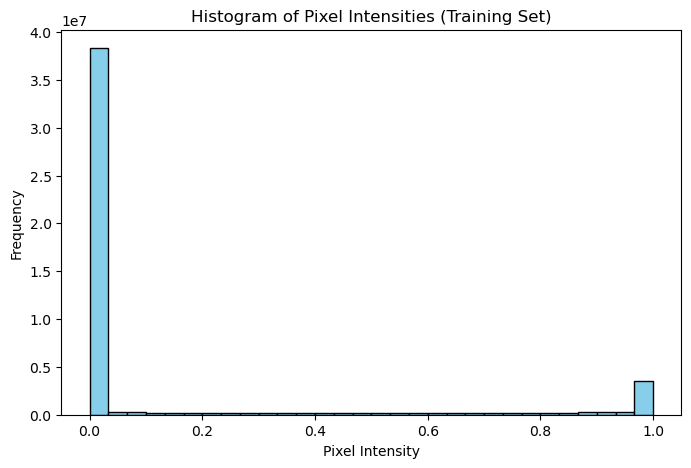

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(x_train.flatten(), bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Histogram of Pixel Intensities (Training Set)')
plt.show()

## Training the Model

### Running the Training

In [ ]:
loss_history, train_acc_history = train(x_train, y_train, x_test, y_test, 30)

epoch: 1   loss: 0.135   train acc: 0.961
